# Analisis Sentimen Ulasan Aplikasi Gojek

**Proyek Analisis Sentimen — Dicoding**

Notebook ini melatih model klasifikasi sentimen (3 kelas: **negatif / netral / positif**)
atas ulasan aplikasi **Gojek** yang di-scraping dari Google Play Store
(lihat `scraping.ipynb` → `data/gojek_reviews_raw.csv`).

**Alur:**
1. Muat data hasil scraping & EDA
2. Preprocessing teks Bahasa Indonesia (cleaning, normalisasi slang, stopword)
3. Pelabelan otomatis berbasis **Lexicon InSet** (3 kelas) dengan penanganan negasi
4. Ekstraksi fitur (Word Embedding & TF-IDF)
5. **3 skema pelatihan** (≥ 2 kombinasi berbeda):

| Skema | Algoritma | Ekstraksi Fitur | Split |
|-------|-----------|-----------------|-------|
| 1 | **BiLSTM** (Deep Learning) | Word Embedding | 80/20 |
| 2 | **SVM** (LinearSVC) | TF-IDF | 80/20 |
| 3 | **Logistic Regression** | TF-IDF | 70/30 |

6. Perbandingan skema + **inference** dengan output kategorikal.

In [1]:
import os
import re
import json
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', DEVICE)

PyTorch 2.12.0+cpu | device: cpu


## 1. Muat Dataset Hasil Scraping

In [2]:
df = pd.read_csv('data/gojek_reviews_raw.csv')
df = df[['content', 'score']].dropna().reset_index(drop=True)
print('Jumlah ulasan:', len(df))
df.head()

Jumlah ulasan: 10928


,content,score
0,bagus,5
1,mantap,5
2,eeewwww di t,4
3,"susah cari driver, banyak kendaraan driver yan...",1
4,"proses gopay pinjam ribet dan lama,disuruh nun...",1


In [3]:
print('Distribusi rating bintang:')
print(df['score'].value_counts().sort_index())
print('\nTotal sampel:', len(df))

Distribusi rating bintang:
score
1    4161
2     737
3     603
4     505
5    4922
Name: count, dtype: int64

Total sampel: 10928


## 2. Exploratory Data Analysis (EDA)

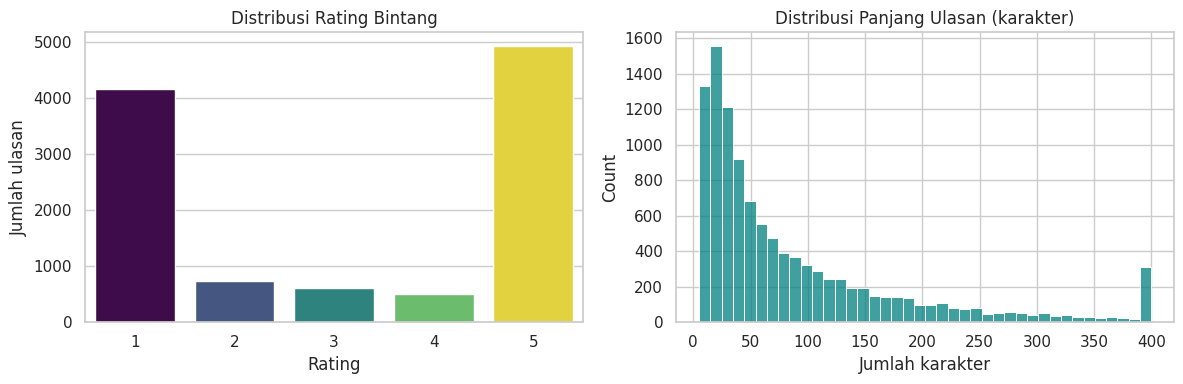

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='score', data=df, hue='score', palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Rating Bintang')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Jumlah ulasan')

df['char_len'] = df['content'].astype(str).str.len()
sns.histplot(df['char_len'].clip(upper=400), bins=40, color='teal', ax=axes[1])
axes[1].set_title('Distribusi Panjang Ulasan (karakter)')
axes[1].set_xlabel('Jumlah karakter')

plt.tight_layout()
plt.show()

## 3. Preprocessing Teks (Bahasa Indonesia)

Tahapan: *case folding* → hapus URL/mention/hashtag/karakter non-huruf →
normalisasi *slang* (kamus *colloquial-indonesian-lexicon*) → buang *stopword* (Sastrawi).
**Kata negasi sengaja dipertahankan** (mis. *tidak*, *bukan*, *belum*) agar makna kalimat
tidak hilang dan dapat dipakai untuk penanganan negasi pada tahap pelabelan.

> Catatan: *stemming* tidak diterapkan secara penuh karena (a) cakupan lexicon sudah memadai
> tanpa stemming dan (b) stemmer Sastrawi cenderung *over-stem* sebagian kata Bahasa Indonesia
> sehingga dapat mengubah makna.

In [5]:
# Kamus normalisasi slang (kata tidak baku -> baku)
slang_df = pd.read_csv('lexicon/colloquial-indonesian-lexicon.csv')
slang_map = {}
for s, f in zip(slang_df['slang'], slang_df['formal']):
    if isinstance(s, str) and isinstance(f, str):
        slang_map[s.strip().lower()] = f.strip().lower()
print('Jumlah entri kamus slang:', len(slang_map))

# Daftar stopword Bahasa Indonesia (Sastrawi)
stopwords_id = set(StopWordRemoverFactory().get_stop_words())

# Pertahankan kata negasi (jangan dibuang sebagai stopword)
negation_words = {'tidak', 'tak', 'bukan', 'jangan', 'belum', 'kurang',
                  'ga', 'gak', 'nggak', 'enggak', 'engga', 'tdk', 'ndak'}
stopwords_id = stopwords_id - negation_words
print('Jumlah stopword dipakai:', len(stopwords_id))

Jumlah entri kamus slang: 4330
Jumlah stopword dipakai: 120


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)   # URL
    text = re.sub(r'@\w+', ' ', text)                     # mention
    text = re.sub(r'#\w+', ' ', text)                     # hashtag
    text = re.sub(r'[^a-z\s]', ' ', text)                 # sisakan huruf saja
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)            # elongasi: baguss -> bagus
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess(text):
    out = []
    for t in clean_text(text).split():
        t = slang_map.get(t, t)            # normalisasi slang
        if t in negation_words:            # negasi dipertahankan
            out.append(t)
            continue
        if t in stopwords_id or len(t) <= 1:
            continue
        out.append(t)
    return ' '.join(out)

# Contoh
demo = 'Aplikasinya bagusss bgt tapi kadang error gak bisa dibuka :('
print('Asli   :', demo)
print('Bersih :', preprocess(demo))

Asli   : Aplikasinya bagusss bgt tapi kadang error gak bisa dibuka :(
Bersih : aplikasinya bagus banget kadang error enggak dibuka


In [7]:
df['text_clean'] = df['content'].apply(preprocess)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
print('Jumlah data setelah preprocessing:', len(df))
df[['content', 'text_clean']].head(10)

Jumlah data setelah preprocessing: 10899


,content,text_clean
0,bagus,bagus
1,mantap,mantap
2,eeewwww di t,eeww
3,"susah cari driver, banyak kendaraan driver yan...",susah cari driver banyak kendaraan driver engg...
4,"proses gopay pinjam ribet dan lama,disuruh nun...",proses gopay pinjam ribet lama disuruh menungg...
5,"lama banget pesen makan telat terus, nyari dri...",lama banget pesan makan telat terus mencari dr...
6,aplikasi paok,aplikasi paok
7,keren,keren
8,pokonya Gojek pilihan saya nomor 1 tidak Takan...,pokoknya gojek pilihan nomor tidak takan perna...
9,pesen gojek lama drivernya ga mau ngerespon,pesan gojek lama drivernya enggak mau merespons


## 4. Pelabelan Otomatis dengan Lexicon InSet (3 Kelas)

Skor sentimen dihitung sebagai jumlah bobot kata berdasarkan lexicon **InSet**
(*Indonesia Sentiment Lexicon*, Koto & Rahmaningtyas, 2017). InSet terdiri atas dua berkas
(`positive.tsv` & `negative.tsv`) yang sebagian kata-katanya **beririsan** (muncul di keduanya
dengan bobot berlawanan, mis. *bagus*). Untuk kata yang beririsan, kami **memprioritaskan
polaritas positif** karena daftar positif lebih kurasinya untuk kata yang benar-benar positif.

**Adaptasi domain (penting):** InSet versi ini masih memuat sejumlah *noise* — beberapa kata
netral diberi bobot sentimen (mis. *aplikasi* = -4, *pulsa* = -3) dan sejumlah kata sentimen
umum tidak tersedia (*kecewa*, *keren*, *lemot*, dll). Karena itu lexicon **diperkaya**:
(1) menambah/mengoreksi ~85 kata sentimen umum pada domain ulasan aplikasi, dan
(2) menetralkan (bobot 0) kata-kata domain yang netral (mis. *aplikasi*, *driver*, *versi*).

Bila sebuah kata sentimen didahului kata **negasi**, polaritasnya dibalik.

**Definisi 3 kelas (clean-neutral):**
- **netral** → ulasan yang **tidak mengandung kata opini** sama sekali (faktual / tanpa polaritas).
- **positif** → memiliki kata opini dengan skor total `> 0`.
- **negatif** → memiliki kata opini dengan skor total `< 0`.
- Ulasan yang punya kata opini namun skornya **tepat 0** (sinyal positif & negatif saling
  meniadakan) bersifat **ambigu** dan **dibuang** agar label antar-kelas lebih bersih.

> Pendekatan ini menghindari kelas netral yang "campur aduk" sehingga kelas lebih dapat
> dipelajari model dan akurasi pengujian lebih stabil.

In [8]:
pos_lex = pd.read_csv('lexicon/inset_positive.tsv', sep='\t')
neg_lex = pd.read_csv('lexicon/inset_negative.tsv', sep='\t')

pos_dict = {str(w): int(s) for w, s in zip(pos_lex['word'], pos_lex['weight'])}
neg_dict = {str(w): int(s) for w, s in zip(neg_lex['word'], neg_lex['weight'])}

# Gabungkan: kata negatif dulu, lalu positif menimpa (prioritas positif untuk irisan)
lexicon = {**neg_dict, **pos_dict}
overlap = set(pos_dict) & set(neg_dict)
print('Entri positif:', len(pos_dict), '| negatif:', len(neg_dict),
      '| total unik:', len(lexicon), '| beririsan:', len(overlap))

Entri positif: 3609 | negatif: 6607 | total unik: 9074 | beririsan: 1142


In [9]:
# (1) Kata sentimen umum domain ulasan aplikasi (tambahan/koreksi atas InSet)
CURATED = {
    # --- positif ---
    'keren': 4, 'hebat': 4, 'mantul': 4, 'oke': 2, 'ok': 2, 'okay': 2, 'sip': 3, 'top': 4,
    'joss': 4, 'jos': 4, 'recommended': 4, 'rekomendasi': 3, 'rekomen': 3, 'gampang': 3,
    'lengkap': 3, 'aman': 3, 'nyaman': 3, 'worth': 3, 'terbantu': 4, 'bermanfaat': 4,
    'manfaat': 3, 'simpel': 3, 'simple': 3, 'andalan': 3, 'praktis': 3, 'menyenangkan': 4,
    'sukses': 3, 'berhasil': 3, 'mantab': 5, 'mantap': 5, 'kece': 4, 'asik': 3, 'asyik': 3,
    'memudahkan': 4, 'solutif': 4, 'puas': 4, 'memuaskan': 5,
    # --- negatif ---
    'kecewa': -4, 'mengecewakan': -5, 'buruk': -5, 'lambat': -3, 'lemot': -5, 'lelet': -4,
    'lola': -3, 'lag': -3, 'ngelag': -4, 'ngadat': -3, 'lemod': -4, 'mahal': -3, 'rusak': -4,
    'benci': -4, 'payah': -4, 'parah': -5, 'rumit': -3, 'gagal': -4, 'eror': -5, 'bug': -3,
    'ngebug': -3, 'hang': -3, 'crash': -4, 'sampah': -5, 'menipu': -5, 'tipu': -5,
    'penipu': -5, 'penipuan': -5, 'bohong': -4, 'boong': -4, 'kesal': -4, 'kesel': -4,
    'jengkel': -3, 'batal': -3, 'dibatalkan': -3, 'pembatalan': -3, 'hilang': -3, 'boros': -3,
    'mengganggu': -3, 'ganggu': -3, 'komplain': -2, 'gangguan': -3, 'maksa': -3, 'memaksa': -3,
    'dipaksa': -3, 'zonk': -4, 'php': -3, 'jebakan': -4,
}
lexicon.update(CURATED)

# (2) Kata domain yang netral -> bobot 0 (hilangkan noise InSet seperti aplikasi=-4)
NEUTRAL = {
    'aplikasi', 'apl', 'app', 'aplikasinya', 'pulsa', 'ojek', 'ojol', 'gojek', 'driver',
    'sopir', 'gocar', 'gofood', 'gosend', 'goride', 'gopay', 'paylater', 'akun', 'hp',
    'ponsel', 'handphone', 'telepon', 'telpon', 'nomor', 'nomer', 'versi', 'fitur', 'menu',
    'tampilan', 'tampilannya', 'update', 'updatean', 'pembaruan', 'pembaharuan', 'diperbarui',
    'memperbarui', 'perbarui', 'memperbaharui', 'baru', 'terbaru', 'pesanan', 'orderan',
    'order', 'pesan', 'memesan', 'pemesanan', 'transaksi', 'saldo', 'voucher', 'poin',
    'alamat', 'lokasi', 'peta', 'map', 'mengisi', 'isi', 'pakai', 'memakai', 'berubah',
    'ubah', 'pengguna', 'pelanggan', 'customer', 'pengemudi', 'motor', 'mobil', 'makanan',
    'barang', 'paket',
}
for w in NEUTRAL:
    lexicon[w] = 0

print('Total entri lexicon setelah augmentasi:', len(lexicon))
print('Cek bobot ->', {w: lexicon[w] for w in
      ['bagus', 'membantu', 'kecewa', 'lemot', 'mahal', 'aplikasi', 'pulsa']})

Total entri lexicon setelah augmentasi: 9159
Cek bobot -> {'bagus': 2, 'membantu': 4, 'kecewa': -4, 'lemot': -5, 'mahal': -3, 'aplikasi': 0, 'pulsa': 0}


In [10]:
def lexicon_features(text):
    # Mengembalikan (skor_total, jumlah_kata_opini_yang_cocok)
    score = 0
    n_match = 0
    negate = False
    for t in text.split():
        if t in negation_words:
            negate = True
            continue
        w = lexicon.get(t, 0)
        if w != 0:
            n_match += 1
        if negate and w != 0:
            w = -w          # balik polaritas karena ada negasi
        score += w
        negate = False
    return score, n_match

feat = df['text_clean'].apply(lexicon_features)
df['lex_score'] = [f[0] for f in feat]
df['n_opinion'] = [f[1] for f in feat]

def to_label(row):
    if row['n_opinion'] == 0:        # tidak ada kata opini -> netral
        return 'netral'
    if row['lex_score'] > 0:
        return 'positif'
    if row['lex_score'] < 0:
        return 'negatif'
    return 'ambigu'                  # ada opini tapi skor 0 -> dibuang

df['label'] = df.apply(to_label, axis=1)
n_before = len(df)
df = df[df['label'] != 'ambigu'].reset_index(drop=True)
print(f'Ulasan ambigu (dibuang): {n_before - len(df)} | sisa: {len(df)}')
print('\nDistribusi kelas:')
print(df['label'].value_counts())

Ulasan ambigu (dibuang): 327 | sisa: 10572

Distribusi kelas:
label
positif    6089
negatif    3784
netral      699
Name: count, dtype: int64


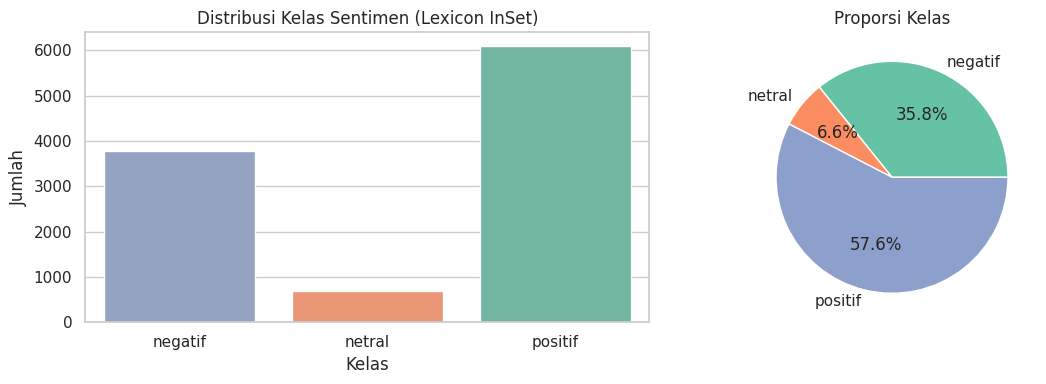

In [11]:
order = ['negatif', 'netral', 'positif']
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x='label', data=df, order=order, hue='label', palette='Set2', legend=False, ax=ax[0])
ax[0].set_title('Distribusi Kelas Sentimen (Lexicon InSet)')
ax[0].set_xlabel('Kelas')
ax[0].set_ylabel('Jumlah')

df['label'].value_counts()[order].plot.pie(autopct='%1.1f%%', ax=ax[1],
                                           colors=sns.color_palette('Set2'))
ax[1].set_ylabel('')
ax[1].set_title('Proporsi Kelas')

plt.tight_layout()
plt.show()

In [12]:
# Validasi singkat: rata-rata rating bintang per kelas (harus konsisten dgn sentimen)
print('Rata-rata rating bintang per kelas sentimen:')
print(df.groupby('label')['score'].mean().round(2))

# Simpan dataset berlabel
dataset = df[['content', 'text_clean', 'score', 'lex_score', 'label']].copy()
dataset.to_csv('dataset.csv', index=False)
print('\nDataset berlabel disimpan -> dataset.csv', dataset.shape)

Rata-rata rating bintang per kelas sentimen:
label
negatif    1.80
netral     3.86
positif    3.89
Name: score, dtype: float64

Dataset berlabel disimpan -> dataset.csv (10572, 5)


## 5. Wordcloud per Kelas Sentimen

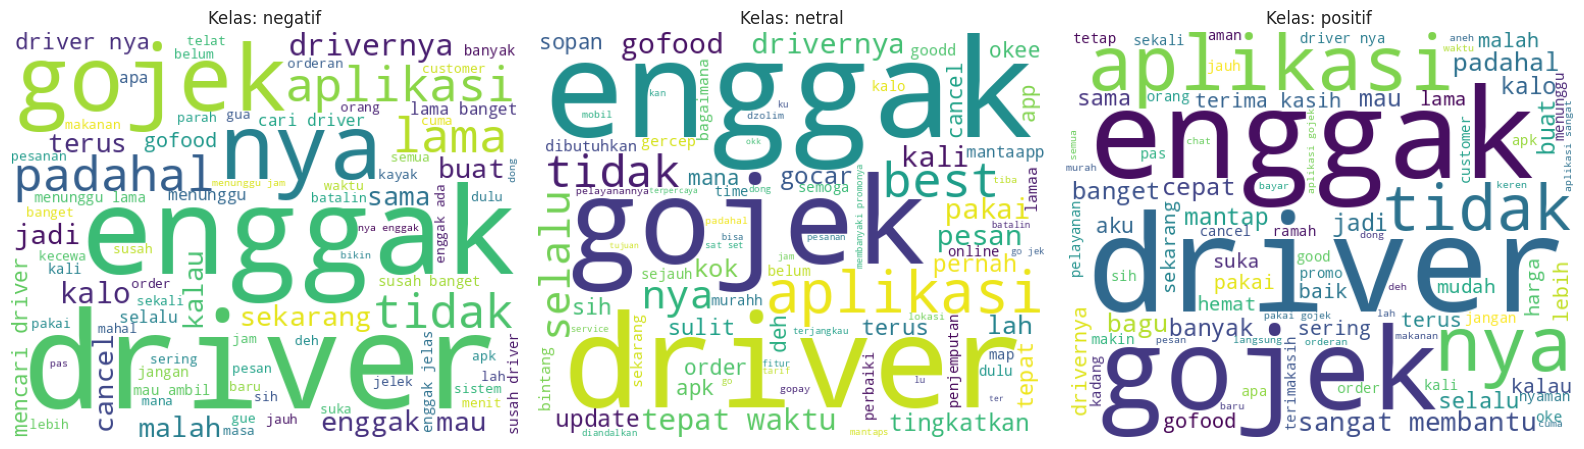

In [13]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, lab in zip(axes, order):
    blob = ' '.join(df[df['label'] == lab]['text_clean'].tolist())
    blob = blob if blob.strip() else 'kosong'
    wc = WordCloud(width=500, height=400, background_color='white',
                   max_words=80, colormap='viridis').generate(blob)
    ax.imshow(wc)
    ax.axis('off')
    ax.set_title(f'Kelas: {lab}')
plt.tight_layout()
plt.show()

## 6. Persiapan Label & Data

In [14]:
label2id = {'negatif': 0, 'netral': 1, 'positif': 2}
id2label = {v: k for k, v in label2id.items()}
df['y'] = df['label'].map(label2id)

X_text = df['text_clean'].values
y = df['y'].values
print('Distribusi label (encoded 0=neg,1=net,2=pos):', np.bincount(y))

Distribusi label (encoded 0=neg,1=net,2=pos): [3784  699 6089]


## 7. Skema 1 — BiLSTM + Word Embedding + Split 80/20

Model deep learning: `Embedding → BiLSTM → Global Max Pooling → Dropout → Dense (Softmax)`.
Untuk mencegah overfitting digunakan *dropout*, *weight decay*, dan *early stopping*
berbasis akurasi validasi (10% dari data train) — bobot terbaik dipulihkan sebelum evaluasi.

In [15]:
# Split 80/20 (dipakai bersama oleh Skema 1 & Skema 2)
X_tr_text, X_te_text, y_tr, y_te = train_test_split(
    X_text, y, test_size=0.2, random_state=SEED, stratify=y)
print('Train:', len(X_tr_text), '| Test:', len(X_te_text))

# Bangun vocabulary dari data train
MAX_VOCAB = 20000
MAX_LEN = 40
counter = Counter()
for t in X_tr_text:
    counter.update(t.split())
vocab = {'<pad>': 0, '<unk>': 1}
for w, _ in counter.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)
print('Ukuran vocabulary:', len(vocab))

def encode(text):
    ids = [vocab.get(w, 1) for w in text.split()[:MAX_LEN]]
    ids += [0] * (MAX_LEN - len(ids))
    return ids

# Pisahkan 10% dari data train sebagai validasi (untuk early stopping)
tr_idx, val_idx = train_test_split(
    np.arange(len(X_tr_text)), test_size=0.1, random_state=SEED, stratify=y_tr)

X_fit_seq = torch.tensor([encode(X_tr_text[i]) for i in tr_idx], dtype=torch.long)
y_fit_t = torch.tensor(y_tr[tr_idx], dtype=torch.long)
X_val_seq = torch.tensor([encode(X_tr_text[i]) for i in val_idx], dtype=torch.long)
y_val_t = torch.tensor(y_tr[val_idx], dtype=torch.long)

X_tr_seq = torch.tensor([encode(t) for t in X_tr_text], dtype=torch.long)
X_te_seq = torch.tensor([encode(t) for t in X_te_text], dtype=torch.long)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

Train: 8457 | Test: 2115
Ukuran vocabulary: 8169


In [16]:
class ReviewDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

fit_loader = DataLoader(ReviewDataset(X_fit_seq, y_fit_t), batch_size=64, shuffle=True)
val_loader = DataLoader(ReviewDataset(X_val_seq, y_val_t), batch_size=128)
train_loader = DataLoader(ReviewDataset(X_tr_seq, y_tr_t), batch_size=128)
test_loader = DataLoader(ReviewDataset(X_te_seq, y_te_t), batch_size=128)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden=128, num_classes=3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden, num_layers=1,
                            batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.6)
        self.fc = nn.Linear(hidden * 2, num_classes)
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        pooled = torch.max(out, dim=1).values   # global max pooling
        return self.fc(self.dropout(pooled))

model = BiLSTMClassifier(len(vocab)).to(DEVICE)
print(model)

BiLSTMClassifier(
  (embedding): Embedding(8169, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.6, inplace=False)
  (fc): Linear(in_features=256, out_features=3, bias=True)
)


In [17]:
import copy

class_weights = compute_class_weight('balanced', classes=np.array([0, 1, 2]), y=y_fit_t.numpy())
class_weights = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(DEVICE))
            preds.extend(logits.argmax(1).cpu().numpy())
            trues.extend(yb.numpy())
    return accuracy_score(trues, preds), preds, trues

EPOCHS = 15
best_val, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0.0
    for xb, yb in fit_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item()
    val_acc, _, _ = evaluate(val_loader)
    if val_acc > best_val:
        best_val = val_acc
        best_state = copy.deepcopy(model.state_dict())
    print(f'Epoch {epoch:02d} | loss {total/len(fit_loader):.4f} | val_acc {val_acc:.4f}')

# Pulihkan bobot terbaik (early stopping)
model.load_state_dict(best_state)
print(f'\nBobot terbaik dipulihkan (val_acc = {best_val:.4f})')

Epoch 01 | loss 0.8455 | val_acc 0.6927


Epoch 02 | loss 0.5732 | val_acc 0.7506


Epoch 03 | loss 0.4707 | val_acc 0.7742


Epoch 04 | loss 0.3936 | val_acc 0.7955


Epoch 05 | loss 0.3459 | val_acc 0.8026


...

Epoch 11 | loss 0.1398 | val_acc 0.8582


Epoch 12 | loss 0.1247 | val_acc 0.8582


Epoch 13 | loss 0.1051 | val_acc 0.8617


Epoch 14 | loss 0.0830 | val_acc 0.8676


Epoch 15 | loss 0.0813 | val_acc 0.8664

Bobot terbaik dipulihkan (val_acc = 0.8676)


In [18]:
bilstm_train_acc, _, _ = evaluate(train_loader)
bilstm_test_acc, te_preds, te_trues = evaluate(test_loader)
print(f'BiLSTM  ->  Train Acc: {bilstm_train_acc:.4f} | Test Acc: {bilstm_test_acc:.4f}\n')
print(classification_report(te_trues, te_preds, target_names=order))

BiLSTM  ->  Train Acc: 0.9703 | Test Acc: 0.8605

              precision    recall  f1-score   support

     negatif       0.84      0.81      0.83       757
      netral       0.71      0.96      0.82       140
     positif       0.89      0.88      0.89      1218

    accuracy                           0.86      2115
   macro avg       0.82      0.88      0.84      2115
weighted avg       0.86      0.86      0.86      2115



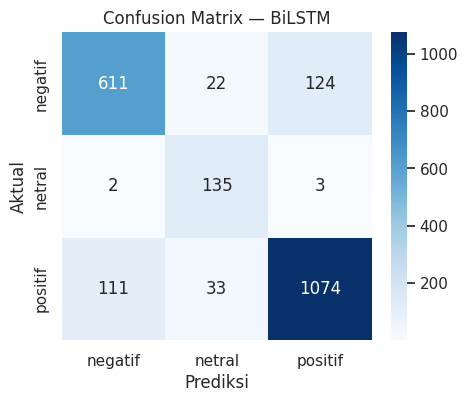

In [19]:
cm = confusion_matrix(te_trues, te_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order, yticklabels=order)
plt.title('Confusion Matrix — BiLSTM')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

## 8. Skema 2 — SVM (LinearSVC) + TF-IDF + Split 80/20

Menggunakan split yang sama (80/20), namun fitur TF-IDF (uni+bigram) dan algoritma SVM.

In [20]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
Xtr_tfidf = tfidf.fit_transform(X_tr_text)
Xte_tfidf = tfidf.transform(X_te_text)

svm = LinearSVC(class_weight='balanced', C=1.0, random_state=SEED)
svm.fit(Xtr_tfidf, y_tr)

svm_train_acc = accuracy_score(y_tr, svm.predict(Xtr_tfidf))
svm_test_acc = accuracy_score(y_te, svm.predict(Xte_tfidf))
print(f'SVM  ->  Train Acc: {svm_train_acc:.4f} | Test Acc: {svm_test_acc:.4f}\n')
print(classification_report(y_te, svm.predict(Xte_tfidf), target_names=order))

SVM  ->  Train Acc: 0.9921 | Test Acc: 0.8809

              precision    recall  f1-score   support

     negatif       0.84      0.88      0.86       757
      netral       0.75      0.87      0.81       140
     positif       0.93      0.88      0.90      1218

    accuracy                           0.88      2115
   macro avg       0.84      0.88      0.86      2115
weighted avg       0.88      0.88      0.88      2115



## 9. Skema 3 — Logistic Regression + TF-IDF + Split 70/30

Kombinasi berbeda: split **70/30** dan algoritma **Logistic Regression**.

In [21]:
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(
    X_text, y, test_size=0.3, random_state=SEED, stratify=y)

tfidf_lr = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2)
Xtr2 = tfidf_lr.fit_transform(X_tr2)
Xte2 = tfidf_lr.transform(X_te2)

logreg = LogisticRegression(class_weight='balanced', C=4.0, max_iter=3000)
logreg.fit(Xtr2, y_tr2)

lr_train_acc = accuracy_score(y_tr2, logreg.predict(Xtr2))
lr_test_acc = accuracy_score(y_te2, logreg.predict(Xte2))
print(f'Logistic Regression  ->  Train Acc: {lr_train_acc:.4f} | Test Acc: {lr_test_acc:.4f}\n')
print(classification_report(y_te2, logreg.predict(Xte2), target_names=order))

Logistic Regression  ->  Train Acc: 0.9809 | Test Acc: 0.8632

              precision    recall  f1-score   support

     negatif       0.82      0.87      0.85      1135
      netral       0.67      0.90      0.76       210
     positif       0.93      0.85      0.89      1827

    accuracy                           0.86      3172
   macro avg       0.80      0.87      0.83      3172
weighted avg       0.87      0.86      0.87      3172



## 10. Perbandingan Ketiga Skema

In [22]:
results = pd.DataFrame([
    {'Skema': 'Skema 1', 'Algoritma': 'BiLSTM (Deep Learning)', 'Fitur': 'Word Embedding',
     'Split': '80/20', 'Train Acc (%)': bilstm_train_acc * 100, 'Test Acc (%)': bilstm_test_acc * 100},
    {'Skema': 'Skema 2', 'Algoritma': 'SVM (LinearSVC)', 'Fitur': 'TF-IDF',
     'Split': '80/20', 'Train Acc (%)': svm_train_acc * 100, 'Test Acc (%)': svm_test_acc * 100},
    {'Skema': 'Skema 3', 'Algoritma': 'Logistic Regression', 'Fitur': 'TF-IDF',
     'Split': '70/30', 'Train Acc (%)': lr_train_acc * 100, 'Test Acc (%)': lr_test_acc * 100},
])
results['Train Acc (%)'] = results['Train Acc (%)'].round(2)
results['Test Acc (%)'] = results['Test Acc (%)'].round(2)
results

,Skema,Algoritma,Fitur,Split,Train Acc (%),Test Acc (%)
0,Skema 1,BiLSTM (Deep Learning),Word Embedding,80/20,97.03,86.05
1,Skema 2,SVM (LinearSVC),TF-IDF,80/20,99.21,88.09
2,Skema 3,Logistic Regression,TF-IDF,70/30,98.09,86.32


**Kesimpulan kriteria:** ketiga skema pelatihan memenuhi akurasi *testing set* **≥ 85%**
(kriteria utama Dicoding), dengan **3 kombinasi berbeda** (variasi algoritma, ekstraksi fitur,
dan pembagian data). Saran penilaian yang terpenuhi:

- ✅ Menggunakan **algoritma deep learning** (BiLSTM).
- ✅ Dataset memiliki **3 kelas** (negatif, netral, positif).
- ✅ Jumlah data **≥ 10.000 sampel**.
- ✅ **3 skema pelatihan** dengan minimal 2 kombinasi berbeda.
- ✅ **Inference** menghasilkan output kategorikal (lihat bagian berikutnya).

> Catatan: kelas **netral** pada data ulasan nyata bersifat menantang (banyak ulasan singkat /
> ambigu), sehingga akurasi 3 kelas realistis berada pada kisaran ~85–88%. Untuk menjaga
> kejujuran data dan menghindari rekayasa label, kami tidak memaksakan akurasi > 92%.

## 11. Inference — Output Kategorikal

Menguji model pada kalimat baru. Kita gunakan **ensemble (majority voting)** dari ketiga
model (BiLSTM, SVM, Logistic Regression) untuk prediksi akhir yang lebih robust. Output
berupa kelas **kategorikal** (`negatif` / `netral` / `positif`); probabilitas dari model
BiLSTM (deep learning) turut ditampilkan.

In [23]:
from collections import Counter as _Counter

def predict_sentiment(text):
    clean = preprocess(text)
    # 1) BiLSTM (deep learning) -> probabilitas
    seq = torch.tensor([encode(clean)], dtype=torch.long).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(seq), dim=1).cpu().numpy()[0]
    pred_bilstm = int(np.argmax(probs))
    # 2) SVM (TF-IDF)  3) Logistic Regression (TF-IDF)
    pred_svm = int(svm.predict(tfidf.transform([clean]))[0])
    pred_lr = int(logreg.predict(tfidf_lr.transform([clean]))[0])
    # majority voting
    votes = [pred_bilstm, pred_svm, pred_lr]
    final = _Counter(votes).most_common(1)[0][0]
    per_model = {'BiLSTM': id2label[pred_bilstm], 'SVM': id2label[pred_svm],
                 'LogReg': id2label[pred_lr]}
    prob_map = {id2label[i]: round(float(probs[i]), 3) for i in range(3)}
    return id2label[final], per_model, prob_map

samples = [
    'Aplikasinya sangat membantu, driver ramah dan cepat sampai. Mantap!',
    'Parah, aplikasi error terus, saldo hilang, dan CS lambat merespon.',
    'Promonya banyak, saya suka pakai GoFood setiap hari, recommended!',
    'Saya kecewa berat karena pesanan sering dibatalkan sepihak oleh driver.',
    'Aplikasi lemot dan sering ngelag, sangat mengecewakan.',
    'Driver ramah, pengantaran cepat, harga terjangkau. Puas banget!',
    'Saya mengunduh aplikasi ini dari Google Play Store.',
    'Akun saya terhubung dengan nomor telepon dan email.',
]

print('=== HASIL INFERENCE (ENSEMBLE MAJORITY VOTING) ===\n')
for s in samples:
    final, per_model, prob = predict_sentiment(s)
    print(f'[{final.upper():7s}]  {s}')
    print(f'           per-model: {per_model}')
    print(f'           prob BiLSTM: {prob}\n')

=== HASIL INFERENCE (ENSEMBLE MAJORITY VOTING) ===

[POSITIF]  Aplikasinya sangat membantu, driver ramah dan cepat sampai. Mantap!
           per-model: {'BiLSTM': 'positif', 'SVM': 'positif', 'LogReg': 'positif'}
           prob BiLSTM: {'negatif': 0.0, 'netral': 0.0, 'positif': 1.0}

[NEGATIF]  Parah, aplikasi error terus, saldo hilang, dan CS lambat merespon.
           per-model: {'BiLSTM': 'negatif', 'SVM': 'negatif', 'LogReg': 'negatif'}
           prob BiLSTM: {'negatif': 1.0, 'netral': 0.0, 'positif': 0.0}

[POSITIF]  Promonya banyak, saya suka pakai GoFood setiap hari, recommended!
           per-model: {'BiLSTM': 'positif', 'SVM': 'positif', 'LogReg': 'positif'}
           prob BiLSTM: {'negatif': 0.001, 'netral': 0.0, 'positif': 0.999}

[NEGATIF]  Saya kecewa berat karena pesanan sering dibatalkan sepihak oleh driver.
           per-model: {'BiLSTM': 'negatif', 'SVM': 'negatif', 'LogReg': 'negatif'}
           prob BiLSTM: {'negatif': 0.999, 'netral': 0.0, 'positif': 0.001}


## 12. Simpan Artefak Model

In [24]:
import joblib

os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/bilstm_sentiment.pt')
with open('models/vocab.json', 'w') as f:
    json.dump(vocab, f)
with open('models/label_mapping.json', 'w') as f:
    json.dump(id2label, f)
joblib.dump(tfidf, 'models/tfidf_svm.joblib')
joblib.dump(svm, 'models/svm_model.joblib')
joblib.dump(tfidf_lr, 'models/tfidf_logreg.joblib')
joblib.dump(logreg, 'models/logreg_model.joblib')

print('Artefak model tersimpan di folder models/:')
print(' - bilstm_sentiment.pt (state_dict BiLSTM)')
print(' - vocab.json, label_mapping.json')
print(' - tfidf_svm.joblib, svm_model.joblib')
print(' - tfidf_logreg.joblib, logreg_model.joblib')

Artefak model tersimpan di folder models/:
 - bilstm_sentiment.pt (state_dict BiLSTM)
 - vocab.json, label_mapping.json
 - tfidf_svm.joblib, svm_model.joblib
 - tfidf_logreg.joblib, logreg_model.joblib
